In [2]:
import json
with open("golgg_games.json") as f:
    games = json.load(f)

print(len(games))
games = list({g["game_id"]:g for g in games}.values())
print(len(games))
games = sorted(games, key=lambda x: (x["date"], x["match_id"], x["game_id"]))


62530
62456


In [3]:
matches = {}
for g in games:
    mid = g["match_id"]
    if mid not in matches:
        matches[mid] = {
            "match_id": mid,
            "date": g["date"],
            "tournament": g["tournament"],
            "name_1": g["t1_name"],
            "name_2": g["t2_name"],
            "tid_1": g["t1_id"],
            "tid_2": g["t2_id"],
            "score_1": 0,
            "score_2": 0,
            "players_1": [p["player_id"] for p in g["t1_players"].values()],
            "players_2": [p["player_id"] for p in g["t2_players"].values()],
            "games": []
        }
    
    t1_win = g["t1_win"]
    if g["t1_id"] != matches[mid]["tid_1"]:
        t1_win = 1 - t1_win  # swap if team ids don't match
    matches[mid]["score_1"] += int(t1_win)
    matches[mid]["score_2"] += int(1 - t1_win)
    matches[mid]["t1_win"] = matches[mid]["score_1"] > matches[mid]["score_2"]
    matches[mid]["BoN"] = max(matches[mid]["score_1"], matches[mid]["score_2"]) * 2 - 1
    matches[mid]["games"].append(g)

matches = list(sorted(matches.values(), key=lambda x: (x["date"], x["match_id"])))

In [4]:
len(matches)

38827

In [5]:
import json 
with open("golgg_matches.json", 'r') as f:
    matches = json.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'golgg_matches.json'

In [10]:
# Init ratings
from collections import defaultdict
from glicko2 import Player
from trueskill import TrueSkill
from openskill.models import PlackettLuce, ThurstoneMostellerFull

ts_model = TrueSkill(draw_probability=0.0)
pl_model = PlackettLuce()
tm_model = ThurstoneMostellerFull()

team_elo = defaultdict(lambda: 1500)
team_gl = defaultdict(lambda: Player())
team_ts = defaultdict(lambda: ts_model.create_rating())
team_pl = defaultdict(lambda: pl_model.rating())
team_tm = defaultdict(lambda: tm_model.rating())
player_elo = defaultdict(lambda: 1500)
player_gl = defaultdict(lambda: Player())
player_ts = defaultdict(lambda: ts_model.create_rating())
player_pl = defaultdict(lambda: pl_model.rating())
player_tm = defaultdict(lambda: tm_model.rating())
y_predicts = {
    "team_elo": [],
    "team_gl": [],
    "team_ts": [],
    "team_pl": [],
    "team_tm": [],
    "player_elo": [],
    "player_gl": [],
    "player_ts": [],
    "player_pl": [],
    "player_tm": [],
    "bon_team_elo": [],
    "bon_team_gl": [],
    "bon_team_ts": [],
    "bon_team_pl": [],
    "bon_team_tm": [],
    "bon_player_elo": [],
    "bon_player_gl": [],
    "bon_player_ts": [],
    "bon_player_pl": [],
    "bon_player_tm": [],
}

In [11]:
from math import sqrt
from statistics import mean
def elo_players_rating(players):
    return sum(player_elo[p] for p in players) / len(players)

def update_team_elo(t1, t2, score_1, score_2, k=32):
    R1 = team_elo[t1]
    R2 = team_elo[t2]
    E1 = 1 / (1 + 10 ** ((R2 - R1) / 400))
    E2 = 1 / (1 + 10 ** ((R1 - R2) / 400))
    S1 = score_1 / (score_1 + score_2)
    S2 = score_2 / (score_1 + score_2)
    team_elo[t1] += k * (S1 - E1)
    team_elo[t2] += k * (S2 - E2)

def update_player_elo(players_1, players_2, score_1, score_2, k=16):
    team_elo_1 = elo_players_rating(players_1)
    team_elo_2 = elo_players_rating(players_2)
    E1 = 1 / (1 + 10 ** ((team_elo_2 - team_elo_1) / 400))

    for player_1 in players_1:
        player_rank = player_elo[player_1]
        E2 = 1 / (1 + 10 ** ((player_rank - team_elo_2) / 400))
        player_elo[player_1] += k * (score_1 - E2)

    for player_2 in players_2:
        player_rank = player_elo[player_2]
        E2 = 1 / (1 + 10 ** ((player_rank - team_elo_1) / 400))
        player_elo[player_2] += k * (score_2 - E2)

player_last_played = {}
team_last_played = {}
from datetime import datetime, date



def apply_time_decay(player: Player, last_played_date, current_date, period_days=7):
    if last_played_date is None:
        return  # nowy gracz - już ma wysokie RD

    days = (current_date - last_played_date).days
    if days <= 0:
        return

    periods = days // period_days
    for _ in range(periods):
        player.did_not_compete()

def get_player_gl(player_id):
    player = player_gl[player_id]
    return player

def update_player_gl_rd(player_id, current_date):
    last_time_played = player_last_played.get(player_id)
    player = player_gl[player_id]
    apply_time_decay(player, last_time_played, current_date)
    player_last_played[player_id] = current_date

def update_team_gl_rd(team_id, current_date):
    last_time_played = team_last_played.get(team_id)
    player = team_gl[team_id]
    apply_time_decay(player, last_time_played, current_date)
    team_last_played[team_id] = current_date

def get_team_gl(team_id) -> Player:
    player = team_gl[team_id]
    return player

def glicko_players_rating(players: list[Player]):
    ratings = [p.rating for p in players]
    rds = [p.rd**2 for p in players]

    return mean(ratings), sqrt(mean(rds))

def update_team_gl(players_1, players_2, scores: list[int]):
    p1: Player = get_team_gl(players_1)
    p2: Player = get_team_gl(players_2)

    rating_list_1 = [p2.rating] * len(scores)
    rd_list_1 = [p2.rd] * len(scores)
    rating_list_2 = [p1.rating] * len(scores)
    rd_list_2 = [p1.rd] * len(scores)

    p1.update_player(rating_list_1, rd_list_1, outcome_list=scores)
    p2.update_player(rating_list_2, rd_list_2, outcome_list=[1 - s for s in scores])
    team_gl[players_1] = p1
    team_gl[players_2] = p2

def update_player_gl(players_1: list[str], players_2: list[str], scores: list[int]):
    p1 = [get_player_gl(p) for p in players_1]
    p2 = [get_player_gl(p) for p in players_2]

    t1_rating, t1_rd = glicko_players_rating(p1)
    t2_rating, t2_rd = glicko_players_rating(p2)
    rating_list_1 = [t2_rating] * len(scores)
    rd_list_1 = [t2_rd] * len(scores)
    rating_list_2 = [t1_rating] * len(scores)
    rd_list_2 = [t1_rd] * len(scores)

    for p, player_id in zip(p1, players_1):
        p.update_player(rating_list_1, rd_list_1, outcome_list=scores)
        player_gl[player_id] = p

    for p, player_id in zip(p2, players_2):
        p.update_player(rating_list_2, rd_list_2, outcome_list=[1 - s for s in scores])
        player_gl[player_id] = p

def update_team_ts(players_1, players_2, score_1, score_2):
    r1 = team_ts[players_1]
    r2 = team_ts[players_2]
    if score_1 > score_2:
        r1, r2 = ts_model.rate([[r1], [r2]])
    else:
        r2, r1 = ts_model.rate([[r2], [r1]])
    team_ts[players_1] = r1[0]
    team_ts[players_2] = r2[0]
    
def update_player_ts(players_1, players_2, score_1, score_2):
    r1 = [player_ts[p] for p in players_1]
    r2 = [player_ts[p] for p in players_2]
    if score_1 > score_2:
        r1, r2 = ts_model.rate([r1, r2])
    else:
        r2, r1 = ts_model.rate([r2, r1])
    for p, player_id in zip(r1, players_1):
        player_ts[player_id] = p
    for p, player_id in zip(r2, players_2):
        player_ts[player_id] = p

def update_team_pl(players_1, players_2, score_1, score_2):
    r1 = team_pl[players_1]
    r2 = team_pl[players_2]
    if score_1 > score_2:
        r1, r2 = pl_model.rate([[r1], [r2]])
    else:
        r2, r1 = pl_model.rate([[r2], [r1]])
    team_pl[players_1] = r1[0]
    team_pl[players_2] = r2[0]

def update_player_pl(players_1, players_2, score_1, score_2):
    r1 = [player_pl[p] for p in players_1]
    r2 = [player_pl[p] for p in players_2]
    if score_1 > score_2:
        r1, r2 = pl_model.rate([r1, r2])
    else:
        r2, r1 = pl_model.rate([r2, r1])
    for p, player_id in zip(r1, players_1):
        player_pl[player_id] = p
    for p, player_id in zip(r2, players_2):
        player_pl[player_id] = p

def update_team_tm(players_1, players_2, score_1, score_2):
    r1 = team_tm[players_1]
    r2 = team_tm[players_2]
    if score_1 > score_2:
        r1, r2 = tm_model.rate([[r1], [r2]])
    else:
        r2, r1 = tm_model.rate([[r2], [r1]])
    team_tm[players_1] = r1[0]
    team_tm[players_2] = r2[0]

def update_player_tm(players_1, players_2, score_1, score_2):
    r1 = [player_tm[p] for p in players_1]
    r2 = [player_tm[p] for p in players_2]
    if score_1 > score_2:
        r1, r2 = tm_model.rate([r1, r2])
    else:
        r2, r1 = tm_model.rate([r2, r1])
    for p, player_id in zip(r1, players_1):
        player_tm[player_id] = p
    for p, player_id in zip(r2, players_2):
        player_tm[player_id] = p

def update_after_game(t1, t2, players_1, players_2, score_1, score_2):
    update_team_elo(t1, t2, score_1, score_2)
    update_player_elo(players_1, players_2, score_1, score_2)
    update_team_ts(t1, t2, score_1, score_2)
    update_player_ts(players_1, players_2, score_1, score_2)
    update_team_pl(t1, t2, score_1, score_2)
    update_player_pl(players_1, players_2, score_1, score_2)
    update_team_tm(t1, t2, score_1, score_2)
    update_player_tm(players_1, players_2, score_1, score_2)

def update_after_match(t1, t2, players_1, players_2, scores):
    update_team_gl(t1, t2, scores)
    update_player_gl(players_1, players_2, scores)

def update_before_match(t1, t2, players_1, players_2, match_date):
    for p in players_1:
        update_player_gl_rd(p, current_date=match_date)
    for p in players_2:
        update_player_gl_rd(p, current_date=match_date)

    update_team_gl_rd(t1, current_date=match_date)
    update_team_gl_rd(t2, current_date=match_date)
    

In [12]:
# prediction cell
from math import comb
import math
import trueskill
def match_win_probability(p: float, bon: int) -> float:
    wins_needed = bon // 2 + 1
    probability = 0.0

    for k in range(wins_needed, bon + 1):
        probability += comb(bon, k) * (p ** k) * ((1 - p) ** (bon - k))

    return probability

print(match_win_probability(0.6, 3))  # best of 3
print(match_win_probability(0.6, 5))  # best of 5

def expected_ts_score(team_a: list[trueskill.Rating], team_b: list[trueskill.Rating]):
    mu_a = sum(r.mu for r in team_a)
    mu_b = sum(r.mu for r in team_b)

    sigma2_a = sum(r.sigma ** 2 for r in team_a)
    sigma2_b = sum(r.sigma ** 2 for r in team_b)

    delta_mu = mu_a - mu_b
    denom = sqrt(sigma2_a + sigma2_b + 2 * ts_model.beta ** 2)

    return ts_model.cdf(delta_mu / denom)

def g(rd):
    return 1 / math.sqrt(1 + 3 * (rd ** 2) / (math.pi ** 2))

def expected_gl_score(player_i, player_j):

    ri = player_i.rating
    rj = player_j.rating
    RDi = player_i.rd
    RDj = player_j.rd

    combined_rd = math.sqrt(RDi**2 + RDj**2)
    g_factor = g(combined_rd)

    exponent = -g_factor * (ri - rj) / 400

    E = 1 / (1 + 10 ** exponent)
    return E

def predict_match(t1, t2, players_1, players_2):
    predictions = {}
    # Team Elo
    r1 = team_elo[t1]
    r2 = team_elo[t2]
    E1 = 1 / (1 + 10 ** ((r2 - r1) / 400))
    predictions["team_elo"] = E1

    # Team Glicko
    p1 = team_gl[t1]
    p2 = team_gl[t2]
    glicko_E1 = expected_gl_score(p1, p2)
    predictions["team_gl"] = glicko_E1

    # Team TrueSkill
    r1 = team_ts[t1]
    r2 = team_ts[t2]
    ts_E1 = expected_ts_score([r1], [r2])
    predictions["team_ts"] = ts_E1

    # Team PlackettLuce
    r1 = team_pl[t1]
    r2 = team_pl[t2]
    pl_E1 = pl_model.predict_win([[r1], [r2]])[0]
    predictions["team_pl"] = pl_E1

    # Team ThurstoneMostellerFull
    r1 = team_tm[t1]
    r2 = team_tm[t2]
    tm_E1 = tm_model.predict_win([[r1], [r2]])[0]
    predictions["team_tm"] = tm_E1

    # Player Elo
    team_elo_1 = elo_players_rating(players_1)
    team_elo_2 = elo_players_rating(players_2)
    E1 = 1 / (1 + 10 ** ((team_elo_2 - team_elo_1) / 400))
    predictions["player_elo"] = E1

    # Player Glicko
    p1 = [player_gl[p] for p in players_1]
    p2 = [player_gl[p] for p in players_2]
    t1_rating, t1_rd = glicko_players_rating(p1)
    t2_rating, t2_rd = glicko_players_rating(p2)
    glicko_E1 = expected_gl_score(Player(t1_rating, t1_rd), Player(t2_rating, t2_rd))
    predictions["player_gl"] = glicko_E1

    # Player TrueSkill
    r1 = [player_ts[p] for p in players_1]
    r2 = [player_ts[p] for p in players_2]
    ts_E1 = expected_ts_score(r1, r2)
    predictions["player_ts"] = ts_E1

    # Player PlackettLuce
    r1 = [player_pl[p] for p in players_1]
    r2 = [player_pl[p] for p in players_2]
    pl_E1 = pl_model.predict_win([r1, r2])[0]
    predictions["player_pl"] = pl_E1

    # Player ThurstoneMostellerFull
    r1 = [player_tm[p] for p in players_1]
    r2 = [player_tm[p] for p in players_2]
    tm_E1 = tm_model.predict_win([r1, r2])[0]
    predictions["player_tm"] = tm_E1    
    
    return predictions


def add_bon_predictions(predictions, bon):
    for key in list(predictions.keys()):
        p = predictions[key]
        bon_p = match_win_probability(p, bon)
        predictions[f"bon_{key}"] = bon_p

def add_to_y_predicts(y_predicts, predictions):
    for key, value in predictions.items():
        y_predicts[key].append(value)


0.648
0.68256


In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm import tqdm
from dateutil.relativedelta import relativedelta
from datetime import date
import pandas as pd
y_trues = []
interval_y_true = []
INTERVAL_YEARS = 2
interval_predictions = []
end_date = date.fromisoformat("2014-01-01")
aucs = []
for match in tqdm(matches, desc="Processing matches"):
    mid = match["match_id"]
    t1 = match["tid_1"]
    t2 = match["tid_2"]
    match_date = date.fromisoformat(match["date"])
    players_1 = match["players_1"]
    players_2 = match["players_2"]
    scores = []
    update_before_match(t1, t2, players_1, players_2, match_date)
    predictions = predict_match(t1, t2, players_1, players_2)
    add_bon_predictions(predictions, match["BoN"])

    interval_predictions.append({
        "date": match_date,
        **predictions
    })
    interval_y_true.append({"date": match_date, "y_true": int(match["t1_win"])})

    add_to_y_predicts(y_predicts, predictions)

    if match_date >= end_date:
        end_date += relativedelta(months=2)
        df = pd.DataFrame(interval_predictions)
        X = df["player_gl"]
        y = pd.DataFrame(interval_y_true)["y_true"]
        if len(set(y)) > 2:        
            auc = roc_auc_score(y, X)
            acc = accuracy_score(y, [1 if p >= 0.5 else 0 for p in X])
            aucs.append({
                "date": end_date, "auc": auc, "accuracy": acc, "n_matches": len(y)})
        back_date = end_date 
        interval_predictions = [pred for pred in interval_predictions if pred["date"] >= end_date - relativedelta(months=2)]
        interval_y_true = [yt for yt in interval_y_true if yt["date"] >= end_date - relativedelta(months=2)]

    y_trues.append(int(match["t1_win"]))
    for game in match["games"]:
        score_1 = int(game["t1_win"])
        score_2 = 1 - score_1
        if game["t1_id"] != match["tid_1"]:
            score_1, score_2 = score_2, score_1  # swap if team ids don't match

        scores.append(score_1)
        update_after_game(t1, t2, players_1, players_2, score_1, score_2)

    update_after_match(t1, t2, players_1, players_2, scores)

Processing matches:   0%|          | 0/38827 [00:00<?, ?it/s]

Processing matches: 100%|██████████| 38827/38827 [01:24<00:00, 457.77it/s]


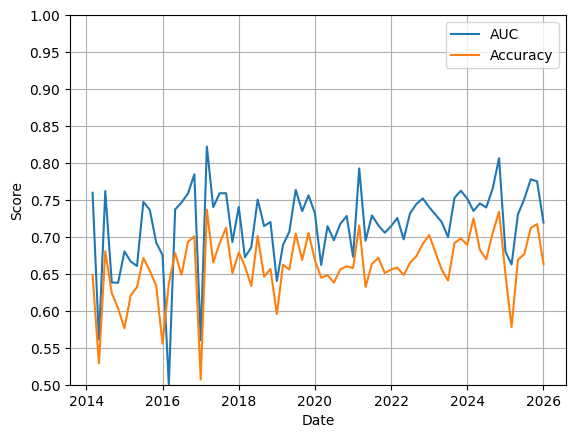

In [14]:
# plot auc history
import matplotlib.pyplot as plt
df = pd.DataFrame(aucs)
plt.plot(df["date"], df["auc"], label="AUC")
plt.plot(df["date"], df["accuracy"], label="Accuracy")
plt.ylim(0.5, 1.0)
plt.yticks([i / 100 for i in range(50, 101, 5)])
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Score")
plt.legend()
plt.show()

In [15]:
import pandas as pd
df = pd.DataFrame(y_predicts)
df["y_true"] = y_trues

X = df.drop(columns=["y_true"])
y = df["y_true"]

metrics = {
    "Team Elo": "team_elo",
    "Team Glicko": "team_gl",
    "Team TrueSkill": "team_ts",
    "Team PlackettLuce": "team_pl",
    "Team ThurstoneMostellerFull": "team_tm",
    "Player Elo": "player_elo",
    "Player Glicko": "player_gl",
    "Player TrueSkill": "player_ts",
    "Player PlackettLuce": "player_pl",
    "Player ThurstoneMostellerFull": "player_tm",
    "Bon Team Elo": "bon_team_elo",
    "Bon Team Glicko": "bon_team_gl",
    "Bon Team TrueSkill": "bon_team_ts",
    "Bon Team PlackettLuce": "bon_team_pl",
    "Bon Team ThurstoneMostellerFull": "bon_team_tm",
    "Bon Player Elo": "bon_player_elo",
    "Bon Player Glicko": "bon_player_gl",
    "Bon Player TrueSkill": "bon_player_ts",
    "Bon Player PlackettLuce": "bon_player_pl",
    "Bon Player ThurstoneMostellerFull": "bon_player_tm"
}


# Plot ROC
from sklearn.metrics import roc_auc_score, roc_curve, roc_curve
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
aucs = {}
for name, col in metrics.items():
    auc = roc_auc_score(y, X[col])
    aucs[name] = auc
    plt.plot([], [], label=f"{name} (AUC = {auc:.3f})")
    fpr, tpr, _ = roc_curve(y, X[col])
    plt.plot(fpr, tpr)

aucs = dict(sorted(aucs.items(), key=lambda item: item[1], reverse=True))
print("AUC Scores:")
for name, auc in aucs.items():
    print(f"{name}: {auc:.3f}")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Match Outcome Predictions')
plt.legend(loc="lower right")
plt.show()

ValueError: Length of values (38826) does not match length of index (38827)